## Hypothesis Testing: Chi-Square Test within the Eniac case study

In [142]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## Given that the decision was reached to test all four versions of the button:

- White “SHOP NOW”
- Red “SHOP NOW”
- White “SEE DEALS”
- Red “SEE DEALS”

# Questions to answer
- What was the click-through rate for each version?
- Which version was the winner?
- Do the results seem conclusive?

## 1.&nbsp; State the Null Hypothesis and the Alternative Hypothesis.

**Null Hypothesis ($H_0$):** All versions have the same click-through rate (CTR).

**Alternative Hypothesis ($H_A$):** The click-through rate (CTR) for at least one version of the website differs.  

## Given
- A statistical significance of 95% was chosen (alpha = 0.5)
- Minimum detectable effect of 20%
- Average of 7142 visitors per day
- Sample size is 19,784
- 4 variations
- Required duration is 14 days

## 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

In [143]:
alpha = 0.5

## 3.&nbsp; Collect Data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them.

Importing the csv's

In [144]:
# eniac_a.csv
url = 'https://drive.google.com/file/d/1PmgcassKDUc9sMK7R8c4RQ5wb6XTaO77/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
eniacA_df = pd.read_csv(path)

# eniac_b.csv
url = 'https://drive.google.com/file/d/1XeVPZAsu6ErbDn2GPKaYJNvmU0kpqpm5/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
eniacB_df = pd.read_csv(path)

# eniac_c.csv
url = 'https://drive.google.com/file/d/1D2tp525XnriqG3Kk9qb1pIw1GMR1ZgSP/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
eniacC_df = pd.read_csv(path)

# eniac_d.csv
url = 'https://drive.google.com/file/d/10dJs_AGoLviidTeSCOG1JhrwhaQW3zGc/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
eniacD_df = pd.read_csv(path)

In [145]:
pd.set_option('display.max_colwidth', None)

In [146]:
eniacA_df

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • https://eniac.com/index-a.php
1,25,div,mySidebar,309,True,"created 2021-09-14 • 14 days 0 hours 34 mins • 25326 visits, 23174 clicks"
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN
5,36,a,Chargers & Cables,1261,False,NaN
6,99,a,iPhone Accessories,1226,False,NaN
7,68,a,Watch Accessories,1261,False,NaN
8,13,a,Mac Accessories,1308,False,NaN
9,15,a,AirTag,206,False,NaN


In [147]:
eniacB_df

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,236,True,Homepage Version B - red SHOP NOW • https://eniac.com/index-b.php
1,25,div,mySidebar,304,True,"created 2021-10-27 • 14 days 0 hours 34 mins • 24747 visits, 22407 clicks"
2,4,a,Mac,268,True,NaN
3,69,a,iPhone,260,True,NaN
4,105,a,Accessories,1214,True,NaN
5,36,a,Chargers & Cables,1259,False,NaN
6,99,a,iPhone Accessories,1237,False,NaN
7,68,a,Watch Accessories,1221,False,NaN
8,13,a,Mac Accessories,1210,False,NaN
9,15,a,AirTag,195,False,NaN


In [148]:
eniacC_df

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,288,True,Homepage Version C - white SEE DEALS • https://eniac.com/index-c.php
1,25,div,mySidebar,283,True,"created 2021-10-27 • 14 days 0 hours 34 mins • 24876 visits, 23031 clicks"
2,4,a,Mac,262,True,NaN
3,69,a,iPhone,234,True,NaN
4,105,a,Accessories,1288,True,NaN
5,36,a,Chargers & Cables,1224,False,NaN
6,99,a,iPhone Accessories,1175,False,NaN
7,68,a,Watch Accessories,1264,False,NaN
8,13,a,Mac Accessories,1203,False,NaN
9,15,a,AirTag,202,False,NaN


In [149]:
eniacD_df

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,285,True,Homepage Version D - red SEE DEALS • https://eniac.com/index-d.php
1,25,div,mySidebar,305,True,"created 2021-10-27 • 14 days 0 hours 34 mins • 25233 visits, 22743 clicks"
2,4,a,Mac,274,True,NaN
3,69,a,iPhone,243,True,NaN
4,105,a,Accessories,1267,True,NaN
5,36,a,Chargers & Cables,1260,False,NaN
6,99,a,iPhone Accessories,1296,False,NaN
7,68,a,Watch Accessories,1252,False,NaN
8,13,a,Mac Accessories,1273,False,NaN
9,15,a,AirTag,201,False,NaN


## We need the number of clicks and vist to create our contingency table

In [150]:
# Checking the Snapshot information column to find total visits and clicks
print("Version A - Snapshot information:")
print(eniacA_df['Snapshot information'].unique())

print("Version B - Snapshot information:")
print(eniacB_df['Snapshot information'].unique())

print("Version C - Snapshot information:")
print(eniacC_df['Snapshot information'].unique())

print("Version D - Snapshot information:")
print(eniacD_df['Snapshot information'].unique())

Version A - Snapshot information:
['Homepage Version A - white SHOP NOW   •   https://eniac.com/index-a.php'
 'created 2021-09-14   •   14 days 0 hours 34 mins   •   25326 visits, 23174 clicks'
 nan]
Version B - Snapshot information:
['Homepage Version B - red SHOP NOW   •   https://eniac.com/index-b.php'
 'created 2021-10-27   •   14 days 0 hours 34 mins   •   24747 visits, 22407 clicks'
 nan]
Version C - Snapshot information:
['Homepage Version C - white SEE DEALS   •   https://eniac.com/index-c.php'
 'created 2021-10-27   •   14 days 0 hours 34 mins   •   24876 visits, 23031 clicks'
 nan]
Version D - Snapshot information:
['Homepage Version D - red SEE DEALS   •   https://eniac.com/index-d.php'
 'created 2021-10-27   •   14 days 0 hours 34 mins   •   25233 visits, 22743 clicks'
 nan]


Number of vists : 25326, 24747, 24876, 25233

Number of clicks: 23174, 22407, 23031, 22743

**Creating the contingency table**

In [181]:
Click = [512, 281, 527, 193]
No_click = [24814, 24466, 24349, 25040]

observed_results = pd.DataFrame([Click, No_click],
                                  columns = ["Version_A", "Version_B", "Version_C", "Version_D"],
                                  index = ["Click", "No-click"])
observed_results

,Version_A,Version_B,Version_C,Version_D
Click,512,281,527,193
No-click,24814,24466,24349,25040


### 4.&nbsp; Calculate the test result.

In [182]:
chisq, pvalue, df, expected = stats.chi2_contingency(observed_results)

In [183]:
chisq

np.float64(224.01877488058412)

In [184]:
pvalue

np.float64(2.7161216607868712e-48)

In [185]:
df

3

In [186]:
expected

array([[  382.48625502,   373.74189974,   375.69012397,   381.08172127],
       [24943.51374498, 24373.25810026, 24500.30987603, 24851.91827873]])

### 5.&nbsp; Interpret the test result.

In [187]:
if pvalue > alpha:
  print("Do not reject the null hypothesis")
else:
  print("Reject the null hypothesis")

Reject the null hypothesis


Since the p-value is smaller than alpha, we will reject the Null Hypothesis. Therefore, the four versions have not performed equally well.

But which version is the best one?



In [199]:
# calculate the click through rate for each version
ctr_a = observed_results.loc["Click", "Version_A"] / sum(observed_results["Version_A"])
ctr_b = observed_results.loc["Click", "Version_B"] / sum(observed_results["Version_B"])
ctr_c = observed_results.loc["Click", "Version_C"] / sum(observed_results["Version_C"])
ctr_d = observed_results.loc["Click", "Version_D"] / sum(observed_results["Version_D"])

# display a DataFrame
ctr = [ctr_a, ctr_b, ctr_c, ctr_d]
names = ["Version_A", "Version_B", "Version_C", "Version_D"]

ctr_df = pd.DataFrame({"ctr": ctr, "names": names})
ctr_df.sort_values("ctr", ascending=False)

,ctr,names
2,0.021185,Version_C
0,0.020216,Version_A
1,0.011355,Version_B
3,0.007649,Version_D


Version C exhibits a significantly higher click-through rate compared to versions B and D, whereas the difference between versions A and C is relatively minor.

Given the similarity between versions A and C, we will declare both versions as the victors with an emphasis on the C.

## **Post-hoc test**

> **In brief:** Post hoc tests, also known as post hoc comparisons or pairwise comparisons, are statistical procedures used in conjunction with a Chi-Squared test to determine specific differences between groups or conditions after obtaining significant results from the Chi-Squared test. Once the Chi-Squared test reveals a significant difference among the variables being examined, post hoc tests are employed to identify which specific groups or categories are significantly different from each other.

Following a Chi-Square test that includes an explanatory variable with 3 or more groups, we need to subset to each possible paired comparison.

There are 6 possible comparisms
- Version A - Version B
- Version A - Version C
- Version A - Version D
- Version B - Version C
- Version B - Version D
- Version C - Version D

The level of alpha we selected for the chi-squared test cannot be same for the dual tests. If there was an error of 5% in each of the tests, this would sum up to much more than the 5% total we set for alpha (nearly 26%), so we will need to be much more restrictive in the dual tests. Therefore, we will split the value of alpha equally among the dual tests to be performed.

This is what's called the Bonferroni Correction!

When interpreting these paired comparisons, rather than setting the α-level (p-value) at 0.5, we divide 0.5 by the number of paired comparisons that we will be making. The result is our new α-level (p-value).

## Remember: If p is low, the Null must go!

In [190]:
alpha = 0.5
possible_combinations = 6

In [191]:
alpha_post_hoc = alpha / possible_combinations
alpha_post_hoc

0.08333333333333333

Let's decide to look at the click-through rates of the different versions. They might help us to declare a winner.

In [194]:
# calculate the click through rate for each version
ctr_a = observed_results.loc["Click", "Version_A"] / sum(observed_results["Version_A"])
ctr_b = observed_results.loc["Click", "Version_B"] / sum(observed_results["Version_B"])
ctr_c = observed_results.loc["Click", "Version_C"] / sum(observed_results["Version_C"])
ctr_d = observed_results.loc["Click", "Version_D"] / sum(observed_results["Version_D"])

# display as DataFrame
ctr = [ctr_a, ctr_b, ctr_c, ctr_d]
names = ["Version_A", "Version_B", "Version_C", "Version_D"]

ctr_df = pd.DataFrame({"ctr": ctr, "names": names})
ctr_df.sort_values("ctr", ascending=False)

#ctrs.sort_values("CTR", ascending=False)

,ctr,names
2,0.021185,Version_C
0,0.020216,Version_A
1,0.011355,Version_B
3,0.007649,Version_D


Click-through rates comparism using Matplotlib

/tmp/ipykernel_6754/2312572678.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Version", y="CTR", data=ctrs, palette="viridis")


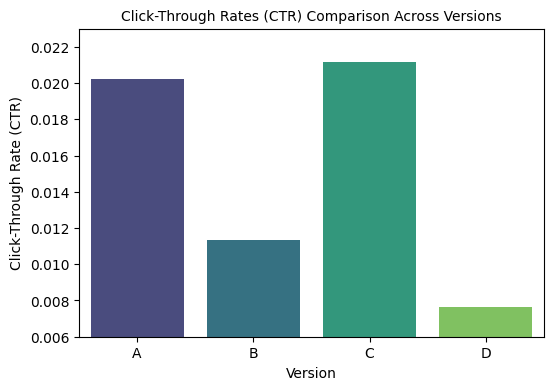

In [195]:
ctrs = pd.DataFrame({
    "Version": ["A", "B", "C", "D"],
    "CTR": [0.020216, 0.011355, 0.021185, 0.007649]
})

ctr_df.sort_values("ctr", ascending=False)

# Plotting the CTRs
plt.figure(figsize=(6, 4))
sns.barplot(x="Version", y="CTR", data=ctrs, palette="viridis")

# Adding title and labels
plt.title("Click-Through Rates (CTR) Comparison Across Versions", fontsize=10)
plt.xlabel("Version", fontsize=10)
plt.ylabel("Click-Through Rate (CTR)", fontsize=10)

# Display the plot
plt.ylim(0.006, 0.023)  # Adjust the y-axis limits to focus on differences
plt.show()

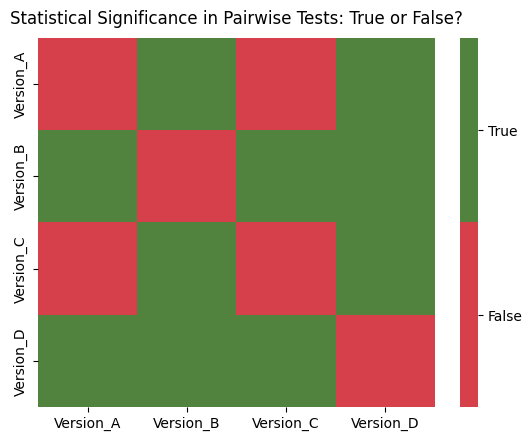

In [197]:
# empty dictionary to fill with our results
stat_significant_dict = {
                         "Version_A": [],
                        "Version_B": [],
                        "Version_C": [],
                        "Version_D": []
                         }

# compare each version to each other version
for i in observed_results.columns:
  for j in observed_results.columns:
        # use scipy to find the p-value of each pair
    chisq, pvalue, df, expected = stats.chi2_contingency(observed_results.loc[:, [i, j]], correction=False)
    # boolean: if the p-value is lower than alpha, our result is statistically significant
    stat_significant_dict[i].append(pvalue < alpha_post_hoc)

# create a DataFrame of results
stat_significant_df = pd.DataFrame(stat_significant_dict,
                                   index=observed_results.columns)

# create a heatmap from the DataFrame & red/green colour palette
red_green_palette = sns.diverging_palette(10, 120, n=2, s=70, l=50)
ax = sns.heatmap(stat_significant_df, cmap=red_green_palette)

# Manually specify colorbar labelling after it's been generated
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0.25, 0.75])
colorbar.set_ticklabels(['False', 'True'])

# Add a title to the heatmap
ax.set_title("Statistical Significance in Pairwise Tests: True or False?", pad=10);

In [198]:
stat_significant_df

,Version_A,Version_B,Version_C,Version_D
Version_A,False,True,False,True
Version_B,True,False,True,True
Version_C,False,True,False,True
Version_D,True,True,True,False


Analysing our heatmap, it is evident that the version with the highest click-through rate, **Version_C**, exhibits a statistically significant difference when compared Versions B and D, but not to **Version_A**, which possesses the second-highest click-through rate. As a result, declaring a clear winner based on post hoc tests becomes challenging, therefore we can only say that both **Version_C and Version_A** are the winners.

However, if a definitive winner is required, additional steps need to be implemented. This is where we transition from the realm of statistics to the business world. The following actions can help in determining the version to be featured on the website in the future:

- Consider other metrics alongside click-through rate.
- Incorporate qualitative research findings.
- Seek input from subject-matter experts.
- Redesign the experiment and conduct it once more.